# Decision Tree Project — Telco Customer Churn
## Dataset Selection and Preprocessing

---

## 1. Mô tả Dataset

### Nguồn dữ liệu
- **Tên dataset:** IBM Telco Customer Churn
- **Nguồn:** IBM Sample Data Sets, công bố công khai trên Kaggle
- **Link:** https://www.kaggle.com/datasets/blastchar/telco-customer-churn
- **Tổ chức cung cấp:** IBM (International Business Machines Corporation)

### Thông tin cơ bản
| Thuộc tính | Giá trị |
|---|---|
| Số mẫu (samples) | 7.043 khách hàng |
| Số đặc trưng gốc (raw features) | 20 (sau khi loại customerID) |
| Số đặc trưng sau encode | 30 |
| Biến mục tiêu (target) | `Churn` — Yes/No |
| Loại bài toán | **Binary Classification** |

### Mô tả các đặc trưng chính
- **Thông tin khách hàng:** `gender`, `SeniorCitizen`, `Partner`, `Dependents`
- **Thông tin hợp đồng:** `tenure` (số tháng sử dụng), `Contract`, `PaperlessBilling`, `PaymentMethod`
- **Dịch vụ sử dụng:** `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`
- **Chi phí:** `MonthlyCharges`, `TotalCharges`
- **Biến mục tiêu:** `Churn` — khách hàng có rời bỏ dịch vụ hay không (Yes = rời bỏ, No = ở lại)

### Lý do dataset phù hợp với Decision Tree
1. **Hỗn hợp categorical và numerical:** Dataset có cả đặc trưng dạng phân loại (Yes/No, loại hợp đồng...) lẫn dạng số (tenure, MonthlyCharges). Decision Tree xử lý tốt cả hai loại sau khi encode.
2. **Dễ diễn giải kết quả:** Decision Tree tạo ra các quy tắc if-else có thể giải thích được (ví dụ: "Nếu hợp đồng Month-to-month VÀ tenure < 12 thì khả năng churn cao"). Điều này rất có giá trị trong bài toán kinh doanh như churn prediction.
3. **Không cần chuẩn hóa:** Decision Tree không yêu cầu scale dữ liệu, phù hợp với dataset có các đặc trưng có đơn vị rất khác nhau (tenure: 0–72, TotalCharges: 0–8000).
4. **Kích thước vừa phải:** 7.043 mẫu là đủ lớn để train/test, không quá nhỏ để underfit cũng không quá lớn để gây vấn đề tính toán.
5. **Bài toán phân loại nhị phân rõ ràng:** Nhãn `Churn` chỉ có 2 giá trị — hoàn toàn phù hợp với Decision Tree Classifier.

---
## 2. Import thư viện

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

---
## 3. Đọc và xem tổng quan dữ liệu

In [8]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("=" * 50)
print(f"Shape ban dau: {df.shape}")
print(f"So mau: {df.shape[0]}")
print(f"So dac trung: {df.shape[1] - 1} (chua tinh cot customerID va Churn)")
print("=" * 50)
df.head()

Shape ban dau: (7043, 21)
So mau: 7043
So dac trung: 20 (chua tinh cot customerID va Churn)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
# Xem kiểu dữ liệu và thông tin tổng quan
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

---
## 4. Làm sạch dữ liệu (Data Cleaning)

**Vấn đề phát hiện:**
- Cột `TotalCharges` kiểu `object` thay vì `float` vì có 11 dòng chứa khoảng trắng `" "`
- Các cột object có thể có khoảng trắng thừa ở đầu/cuối chuỗi

In [10]:
# Bước 1: Xóa khoảng trắng thừa ở tất cả cột dạng string
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

C:\Users\Admin\AppData\Local\Temp\ipykernel_20740\396147551.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [11]:
# Bước 2: Chuyển TotalCharges sang kiểu số
# Các giá trị không hợp lệ (chuỗi rỗng sau strip) sẽ thành NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing values sau khi convert TotalCharges:")
print(df.isnull().sum())

Missing values sau khi convert TotalCharges:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [12]:
# Bước 3: Xóa 11 dòng có TotalCharges bị NaN
# Lý do: 11 dòng này là khách hàng mới (tenure = 0), TotalCharges chưa có giá trị
# → Chiếm ~0.16% tổng dữ liệu, an toàn để xóa
df = df.dropna()
print(f"Shape sau khi xóa NaN: {df.shape}")

Shape sau khi xóa NaN: (7032, 21)


In [13]:
# Bước 4: Kiểm tra và xóa dòng trùng lặp
print(f"So dong trung lap: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Shape sau khi xu ly duplicate: {df.shape}")

So dong trung lap: 0
Shape sau khi xu ly duplicate: (7032, 21)


In [14]:
# Bước 5: Xóa cột customerID (không có giá trị dự đoán)
df = df.drop(columns=["customerID"])
print("Da xoa cot customerID")
print(f"So dac trung con lai: {df.shape[1] - 1} features + 1 target")

Da xoa cot customerID
So dac trung con lai: 19 features + 1 target


---
## 5. Kiểm tra phân phối nhãn (Class Distribution)

Quan trọng với bài toán classification — cần biết dữ liệu có bị imbalanced không.

In [15]:
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100

print("Phan phoi nhan Churn:")
print(f"  No  (khong roi bo): {churn_counts['No']:>5} mau ({churn_pct['No']:.1f}%)")
print(f"  Yes (roi bo):       {churn_counts['Yes']:>5} mau ({churn_pct['Yes']:.1f}%)")
print()
print("Nhan xet: Du lieu bi mat can doi nhe (imbalanced ~73/27).")
print("Su dung stratify=y khi split de dam bao ti le nhan duoc giu nguyen.")

Phan phoi nhan Churn:
  No  (khong roi bo):  5163 mau (73.4%)
  Yes (roi bo):        1869 mau (26.6%)

Nhan xet: Du lieu bi mat can doi nhe (imbalanced ~73/27).
Su dung stratify=y khi split de dam bao ti le nhan duoc giu nguyen.


---
## 6. Encoding

**Phương pháp:** One-Hot Encoding với `pd.get_dummies(drop_first=True)`

- `drop_first=True` loại bỏ 1 cột trong mỗi nhóm để tránh multicollinearity (dummy variable trap)
- Ép kiểu về `int` (0/1) thay vì `bool` để tương thích tốt hơn với sklearn

In [16]:
df_encoded = pd.get_dummies(df, drop_first=True)

bool_cols = df_encoded.select_dtypes(include="bool").columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(f"So dac trung sau encode: {df_encoded.shape[1] - 1} features + 1 target (Churn_Yes)")
print(f"Danh sach cot:")
print(df_encoded.columns.tolist())
df_encoded.head()

So dac trung sau encode: 30 features + 1 target (Churn_Yes)
Danh sach cot:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'Churn_Yes']


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,1


---
## 7. Tách X, y và Chia Train/Test

In [17]:
X = df_encoded.drop(columns=["Churn_Yes"])
y = df_encoded["Churn_Yes"]

print(f"So mau: {X.shape[0]}")
print(f"So feature dung cho model: {X.shape[1]}")
print(f"Phan phoi y: 0 (No) = {(y==0).sum()}, 1 (Yes) = {(y==1).sum()}")

So mau: 7032
So feature dung cho model: 30
Phan phoi y: 0 (No) = 5163, 1 (Yes) = 1869


In [18]:
# Chia 80% train, 20% test
# stratify=y: đảm bảo tỉ lệ churn được giữ nguyên trong cả 2 tập
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Ket qua chia train/test:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train: {y_train.shape} | Churn rate: {y_train.mean()*100:.1f}%")
print(f"  y_test:  {y_test.shape}  | Churn rate: {y_test.mean()*100:.1f}%")

Ket qua chia train/test:
  X_train: (5625, 30)
  X_test:  (1407, 30)
  y_train: (5625,) | Churn rate: 26.6%
  y_test:  (1407,)  | Churn rate: 26.6%


---
## 8. Lưu dữ liệu sạch (Bàn giao)

In [19]:
df_encoded.to_csv("../data/clean/telco_clean.csv", index=False)
X_train.to_csv("../data/clean/X_train.csv", index=False)
X_test.to_csv("../data/clean/X_test.csv", index=False)
y_train.to_csv("../data/clean/y_train.csv", index=False)
y_test.to_csv("../data/clean/y_test.csv", index=False)

print("Da luu thanh cong cac file:")
print("  data/clean/telco_clean.csv  — Toan bo du lieu sach + encoded")
print("  data/clean/X_train.csv      — Tap huan luyen (features)")
print("  data/clean/X_test.csv       — Tap kiem tra (features)")
print("  data/clean/y_train.csv      — Nhan tap huan luyen")
print("  data/clean/y_test.csv       — Nhan tap kiem tra")

Da luu thanh cong cac file:
  data/clean/telco_clean.csv  — Toan bo du lieu sach + encoded
  data/clean/X_train.csv      — Tap huan luyen (features)
  data/clean/X_test.csv       — Tap kiem tra (features)
  data/clean/y_train.csv      — Nhan tap huan luyen
  data/clean/y_test.csv       — Nhan tap kiem tra


---
## 9. Tóm tắt kết quả

| Bước | Kết quả |
|---|---|
| Dataset gốc | 7.043 mẫu, 21 cột |
| Sau làm sạch | 7.032 mẫu (xóa 11 dòng TotalCharges=NaN) |
| Sau encoding | 31 cột (30 features + 1 target `Churn_Yes`) |
| Tập Train | 5.625 mẫu (80%) — Churn rate ≈ 26.5% |
| Tập Test | 1.407 mẫu (20%) — Churn rate ≈ 26.5% |
| Biến mục tiêu | `Churn_Yes`: 0 = Không rời bỏ, 1 = Rời bỏ |

**Dữ liệu sạch đã sẵn sàng để huấn luyện mô hình Decision Tree.**

---
## 10. Baseline Decision Tree Classifier

### 10.1 Train baseline model and evaluate metrics

In [20]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree, _tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    )
import matplotlib.pyplot as plt

# Neu chua co bien train/test trong kernel thi tai tu file clean
if "X_train" not in globals() or "y_train" not in globals():
    X_train = pd.read_csv("../data/clean/X_train.csv")
    X_test = pd.read_csv("../data/clean/X_test.csv")
    y_train = pd.read_csv("../data/clean/y_train.csv").squeeze("columns")
    y_test = pd.read_csv("../data/clean/y_test.csv").squeeze("columns")

y_train = pd.Series(y_train).astype(int)
y_test = pd.Series(y_test).astype(int)

baseline_tree = DecisionTreeClassifier(random_state=42)
baseline_tree.fit(X_train, y_train)

y_train_pred = baseline_tree.predict(X_train)
y_test_pred = baseline_tree.predict(X_test)
y_test_proba = baseline_tree.predict_proba(X_test)[:, 1]

metrics_summary = pd.DataFrame(
    {
        "Metric": ["Accuracy", "Error Rate", "Precision", "Recall", "F1-score", "ROC-AUC"],
        "Value": [
            accuracy_score(y_test, y_test_pred),
            1 - accuracy_score(y_test, y_test_pred),
            precision_score(y_test, y_test_pred, zero_division=0),
            recall_score(y_test, y_test_pred, zero_division=0),
            f1_score(y_test, y_test_pred, zero_division=0),
            roc_auc_score(y_test, y_test_proba),
        ],
    }
)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Baseline Decision Tree (default parameters)")
print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy : {test_acc:.4f}")
display(metrics_summary)
print("\nClassification report (test):")
print(classification_report(y_test, y_test_pred, target_names=["No churn", "Churn"], digits=4))

Baseline Decision Tree (default parameters)
Train accuracy: 0.9988
Test accuracy : 0.7186


,Metric,Value
0,Accuracy,0.718550
1,Error Rate,0.281450
2,Precision,0.470109
3,Recall,0.462567
4,F1-score,0.466307
5,ROC-AUC,0.636638



Classification report (test):
              precision    recall  f1-score   support

    No churn     0.8065    0.8112    0.8089      1033
       Churn     0.4701    0.4626    0.4663       374

    accuracy                         0.7186      1407
   macro avg     0.6383    0.6369    0.6376      1407
weighted avg     0.7171    0.7186    0.7178      1407



### 10.2 Visualize tree and confusion matrix

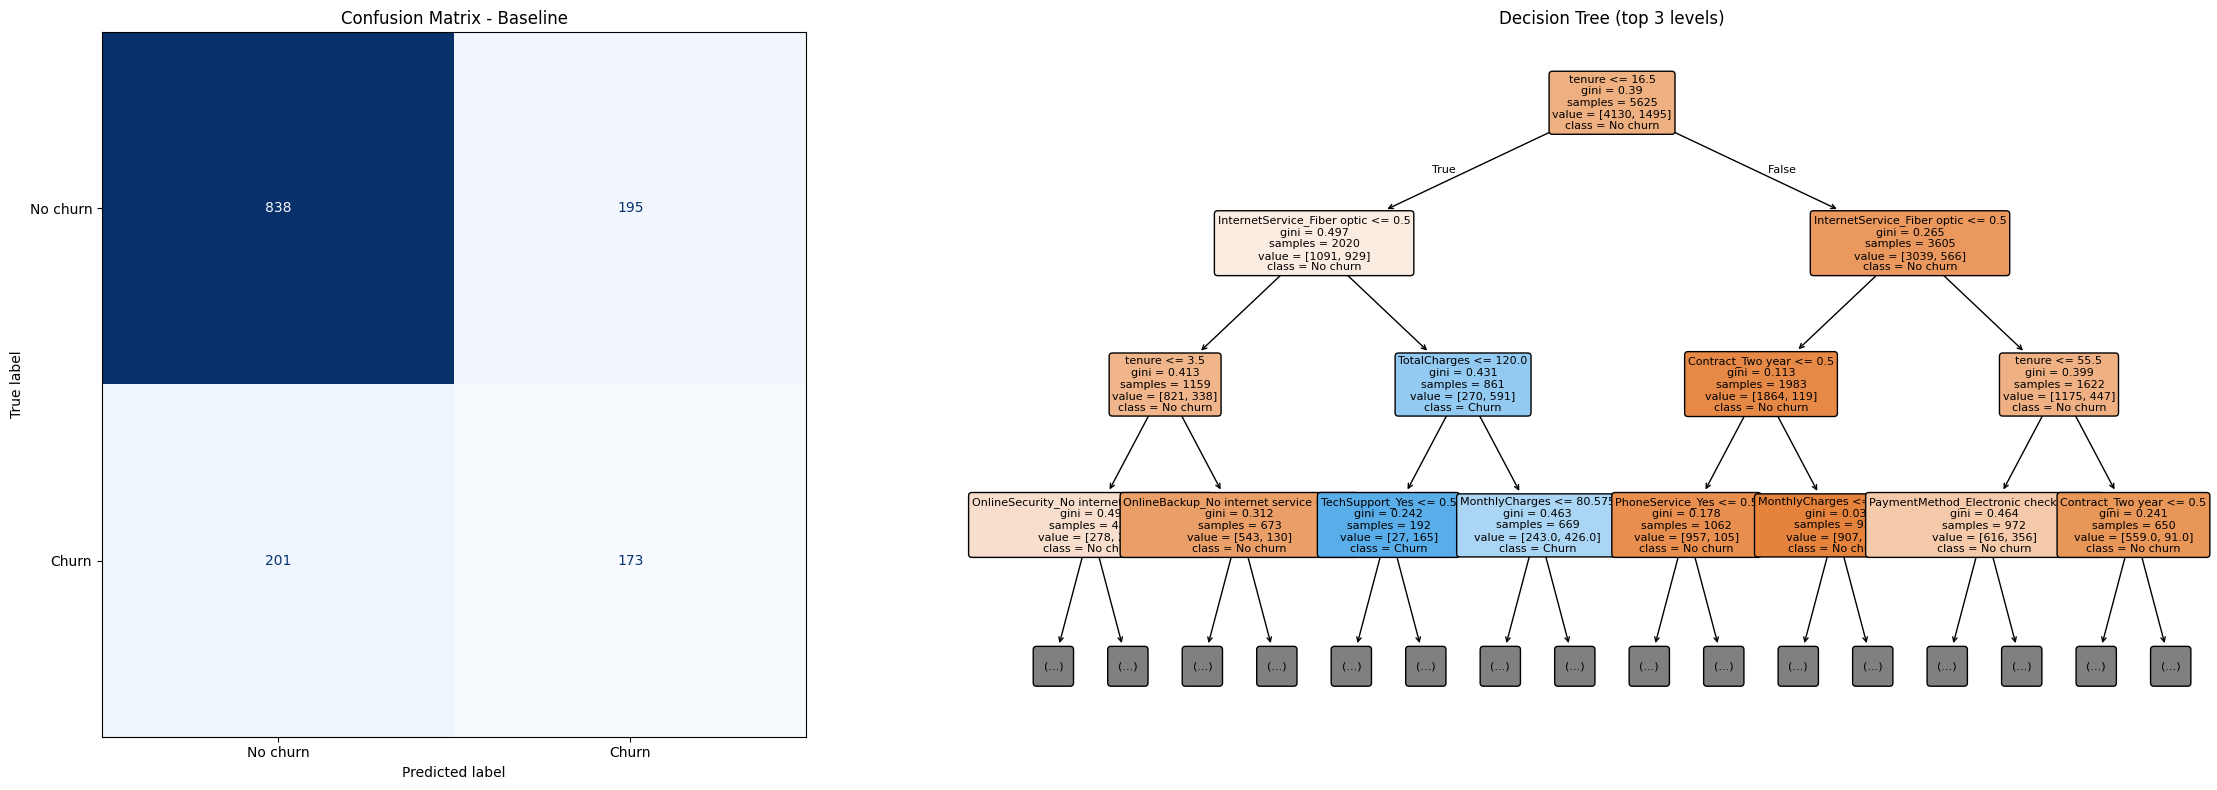

Confusion Matrix:
[[838 195]
 [201 173]]


In [21]:
cm = confusion_matrix(y_test, y_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(24, 8))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No churn", "Churn"]
).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix - Baseline")

plot_tree(
    baseline_tree,
    feature_names=X_train.columns,
    class_names=["No churn", "Churn"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
    ax=axes[1],
)
axes[1].set_title("Decision Tree (top 3 levels)")

plt.tight_layout()
plt.show()

print("Confusion Matrix:")
print(cm)

### 10.3 Tree analysis: depth, nodes/leaves, important splits, decision rules, fit diagnosis

In [22]:
def format_rule(rule_parts):
    return " and ".join(rule_parts) if rule_parts else "ROOT"


def extract_representative_rules(clf, feature_names, max_depth=3):
    tree = clf.tree_
    rules = []

    def recurse(node_id, conditions, current_depth):
        left = tree.children_left[node_id]
        right = tree.children_right[node_id]

        stop_here = (
            left == _tree.TREE_LEAF
            or right == _tree.TREE_LEAF
            or current_depth == max_depth
        )

        if stop_here:
            class_counts = tree.value[node_id][0]
            total = int(tree.n_node_samples[node_id])
            pred_class = int(np.argmax(class_counts))
            count_sum = float(class_counts.sum())
            purity = float(class_counts[pred_class] / count_sum) if count_sum else 0.0
            rules.append(
                {
                    "rule": format_rule(conditions),
                    "samples": total,
                    "pred_class": pred_class,
                    "purity": purity,
                    "depth": current_depth,
                }
            )
            return

        feat_name = feature_names[tree.feature[node_id]]
        threshold = tree.threshold[node_id]
        recurse(
            left,
            conditions + [f"{feat_name} <= {threshold:.3f}"],
            current_depth + 1,
        )
        recurse(
            right,
            conditions + [f"{feat_name} > {threshold:.3f}"],
            current_depth + 1,
        )

    recurse(0, [], 0)
    return rules


depth = baseline_tree.get_depth()
node_count = baseline_tree.tree_.node_count
leaf_count = baseline_tree.get_n_leaves()

importance_df = (
    pd.DataFrame({"feature": X_train.columns, "importance": baseline_tree.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
top_splits = importance_df.head(10)

tree_obj = baseline_tree.tree_
root_id = 0
left_id = tree_obj.children_left[root_id]
right_id = tree_obj.children_right[root_id]

candidate_rules = extract_representative_rules(
    baseline_tree, list(X_train.columns), max_depth=3
)
churn_rules = sorted(
    [r for r in candidate_rules if r["pred_class"] == 1],
    key=lambda x: (x["samples"] * x["purity"]),
    reverse=True,
 )
no_churn_rules = sorted(
    [r for r in candidate_rules if r["pred_class"] == 0],
    key=lambda x: (x["samples"] * x["purity"]),
    reverse=True,
 )

representative_rules = churn_rules[:2] + no_churn_rules[:1]
if len(representative_rules) < 3:
    representative_rules = sorted(
        candidate_rules,
        key=lambda x: (x["samples"] * x["purity"]),
        reverse=True,
    )[:3]

print("Tree structure analysis")
print(f"- Max depth : {depth}")
print(f"- Nodes     : {node_count}")
print(f"- Leaves    : {leaf_count}")

print("\nImportant early splits (root and level 1):")
print(
    f"- Root: {X_train.columns[tree_obj.feature[root_id]]} <= {tree_obj.threshold[root_id]:.3f}"
)
if left_id != _tree.TREE_LEAF:
    print(
        f"- Left child: {X_train.columns[tree_obj.feature[left_id]]} <= {tree_obj.threshold[left_id]:.3f}"
    )
if right_id != _tree.TREE_LEAF:
    print(
        f"- Right child: {X_train.columns[tree_obj.feature[right_id]]} <= {tree_obj.threshold[right_id]:.3f}"
    )

print("\nTop 10 important splits (feature importance):")
display(top_splits)

print("\n2-3 representative decision rules (up to depth 3):")
for idx, rule_item in enumerate(representative_rules, start=1):
    label = "Churn" if rule_item["pred_class"] == 1 else "No churn"
    print(
        f"{idx}. IF {rule_item['rule']} THEN mostly {label} "
        f"(samples={rule_item['samples']}, purity={rule_item['purity']:.2f}, depth={rule_item['depth']})"
    )

gap = train_acc - test_acc
print("\nModel fit diagnosis:")
if gap > 0.08 and depth > 10:
    print(
        f"- Overfit signal: train accuracy ({train_acc:.4f}) is much higher than test accuracy ({test_acc:.4f}), "
        f"gap={gap:.4f}, and tree depth is high ({depth})."
    )
elif train_acc < 0.75 and test_acc < 0.75:
    print(
        f"- Underfit signal: both train ({train_acc:.4f}) and test ({test_acc:.4f}) accuracy are low."
    )
else:
    print(
        f"- Fit is relatively balanced: train={train_acc:.4f}, test={test_acc:.4f}, gap={gap:.4f}."
    )

Tree structure analysis
- Max depth : 23
- Nodes     : 2223
- Leaves    : 1112

Important early splits (root and level 1):
- Root: tenure <= 16.500
- Left child: InternetService_Fiber optic <= 0.500
- Right child: InternetService_Fiber optic <= 0.500

Top 10 important splits (feature importance):


,feature,importance
0,tenure,0.210976
1,TotalCharges,0.199011
2,MonthlyCharges,0.187213
3,InternetService_Fiber optic,0.108336
4,gender_Male,0.027657
5,PaperlessBilling_Yes,0.026147
6,Partner_Yes,0.022470
7,PaymentMethod_Electronic check,0.021341
8,Dependents_Yes,0.020624
9,OnlineBackup_Yes,0.019738



2-3 representative decision rules (up to depth 3):
1. IF tenure <= 16.500 and InternetService_Fiber optic > 0.500 and TotalCharges > 120.000 THEN mostly Churn (samples=669, purity=0.64, depth=3)
2. IF tenure <= 16.500 and InternetService_Fiber optic > 0.500 and TotalCharges <= 120.000 THEN mostly Churn (samples=192, purity=0.86, depth=3)
3. IF tenure > 16.500 and InternetService_Fiber optic <= 0.500 and Contract_Two year <= 0.500 THEN mostly No churn (samples=1062, purity=0.90, depth=3)

Model fit diagnosis:
- Overfit signal: train accuracy (0.9988) is much higher than test accuracy (0.7186), gap=0.2802, and tree depth is high (23).
